In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os
DA_price_data=pd.read_csv('./PJM Day-ahead.csv')
RT_price_data=pd.read_csv('./PJM Real-time.csv')
area_name=set(RT_price_data['pnode_name'])


In [7]:
name_to_code = {
    'Public Service Electric and Gas Company': 'PSEG',
    'Baltimore Gas and Electric Company': 'BGE',
    'Duquesne Light': 'DUQ',
    'Delmarva Power and Light': 'DPL',
    'Pennsylvania Electric Company': 'PENELEC',
    'ComEd': 'COMED',
    'Jersey Central Power and Light Company': 'JCPL',
    'American Electric Power Co., Inc': 'AEP',
    'Dominion Energy': 'DOM',
    'East Kentucky Power Coop': 'EKPC',
    'Metropolitan Edison Company': 'METED',
    'First Energy - Pennsylvania Electric Company': 'PENELEC',
    'Dayton Power and Light Company': 'DAY',
    'Duke Energy Ohio': 'DEOK',
    'Allegheny Power System': 'APS',
    'Atlantic Electric Company': 'AECO',
    'Potomac Electric Power': 'PEPCO',
    'Orion Energy': 'OVEC',
    'Pennsylvania Power and Light Company': 'PPL'
}


In [8]:
def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [9]:
file_name_list=[]
folder_path='Inverse_results_pjm'
for filename in os.listdir(folder_path):
    if '.DS_Store' in filename:
        continue
    print(filename)
    if 'ANN' not in filename and 'informer' not in filename and 'impactnet' not in filename and 'CNN' not in filename\
    and 'autoformer' not in filename and 'LSTM' not in filename and 'nbeats' not in filename and 'proposed' not in filename:
        file_name_list.append(filename[:-4])
        print(name_to_code[filename[8:-4]])

results_First Energy - Pennsylvania Electric Company_informer.csv
results_American Electric Power Co., Inc_nbeats.csv
results_Pennsylvania Electric Company_ANN.csv
results_Public Service Electric and Gas Company.csv
PSEG
results_Jersey Central Power and Light Company_informer.csv
results_Duke Energy Ohio_nbeats.csv
results_Delmarva Power and Light_impactnet.csv
results_Public Service Electric and Gas Company_nbeats.csv
results_Pennsylvania Electric Company_LSTM.csv
results_Baltimore Gas and Electric Company.csv
BGE
results_Orion Energy_CNN.csv
results_Dayton Power and Light Company_informer.csv
results_American Electric Power Co., Inc_autoformer.csv
results_Jersey Central Power and Light Company_autoformer.csv
results_Duquesne Light.csv
DUQ
results_Metropolitan Edison Company_LSTM.csv
results_Dominion Energy_LSTM.csv
results_East Kentucky Power Coop_nbeats.csv
results_Duquesne Light_nbeats.csv
results_Jersey Central Power and Light Company_impactnet.csv
results_Metropolitan Edison Comp

In [10]:
folder_path ='Inverse_results_pjm'
model_list=['autoformer','CNN','impactnet','informer','LSTM','nbeats','ANN']
dataframes = {}
for filename in file_name_list:
    file_path = os.path.join(folder_path, filename+'.csv')
    df = pd.read_csv(file_path)
    #dataframes['Actual'] = df['True']
    #dataframes['Best_Baseline'] = df['Baseline']
    #dataframes['Proposed'] = df['Proposed']
    for model_name in model_list:
        print(model_name)
        file_path = os.path.join(folder_path, filename+'_'+model_name+'.csv')
        df = pd.read_csv(file_path)
        dataframes[model_name] = df['Baseline']
    print(filename)
    dataframes['Proposed'] = df['Proposed']
    dataframes['Actual'] = df['True']
    print([filename[8:]])
    if name_to_code[filename[8:]]=='DOM':
        print(dataframes)
    pd.DataFrame(dataframes).to_csv('process_result/'+name_to_code[filename[8:]]+'.csv', index=False)
    

autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Public Service Electric and Gas Company
['Public Service Electric and Gas Company']
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Baltimore Gas and Electric Company
['Baltimore Gas and Electric Company']
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Duquesne Light
['Duquesne Light']
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Delmarva Power and Light
['Delmarva Power and Light']
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Pennsylvania Electric Company
['Pennsylvania Electric Company']
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_ComEd
['ComEd']
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Jersey Central Power and Light Company
['Jersey Central Power and Light Company']
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_American Electric Power Co., Inc
['American Electric Power Co., Inc']
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

folder_path ='Inverse_results_pjm'
price_start=48
price_end=408
forecasts_start=0
forecasts_end=360
length=forecasts_end-forecasts_start


DA_price_data = pd.read_csv('./PJM Day-ahead.csv')
RT_price_data = pd.read_csv('./PJM Real-time.csv')
model_list = ['autoformer', 'CNN', 'impactnet', 'informer', 'LSTM', 'nbeats', 'ANN']
total_costs={}
for model in model_list:
    total_costs[model]=0
total_costs['proposed']=0

total_avoided_load_loss={}
for model in model_list:
    total_avoided_load_loss[model]=0
total_avoided_load_loss['proposed']=0


if not os.path.exists('results'):
    os.makedirs('results')

cost_saving_all = {}
benchmark_acc = {}
proposed_acc = {}
voll_devitation = []
deviation_proposed_set = {}
deviation_baseline_set = {}
cost_actual_all=[]
cost_model_all=[0,0,0,0,0,0,0,0]

node_code_list=[]
for filename in file_name_list:
    node_code = name_to_code[filename[8:]]
    node_code_list.append(node_code)


for node_code in set(node_code_list):
    #node_code = name_to_code[filename[8:]]
    df = pd.read_csv('process_result/' + node_code + '.csv')

    DA_price = DA_price_data[DA_price_data['pnode_name'] == node_code].iloc[price_start:price_end]['total_lmp_da'].tolist()
    RT_price = RT_price_data[RT_price_data['pnode_name'] == node_code].iloc[price_start:price_end]['total_lmp_rt'].tolist()

    actual_load = df['Actual'][forecasts_start:forecasts_end]
    #print(len(actual_load),len(df),forecasts_start,forecasts_end)
    proposed_forecasts = df['Proposed'][forecasts_start:forecasts_end]

    # 保存每个模型的结果
    results = []

    # Proposed
    mape_proposed = MAPE(actual_load, proposed_forecasts)
    proposed_acc[node_code] = mape_proposed
    deviation_proposed = np.array(actual_load) - np.array(proposed_forecasts)
    deviation_proposed[deviation_proposed < 0] = 0
    deviation_proposed_set[node_code] = deviation_proposed
    cost_actual = np.array(actual_load) * np.array(DA_price)
    # avoided_load_loss = deviation_proposed
    # avoided_load_loss[avoided_load_loss < 0] = 0
    #print(len(actual_load),len(DA_price))
    cost_actual_all.append(np.sum(cost_actual))
    costs_proposed = np.array(proposed_forecasts) * np.array(DA_price) + (np.array(actual_load) - np.array(proposed_forecasts)) * np.array(RT_price)
    results.append({
        'model': 'Proposed',
        'mape': mape_proposed,
        'cost': np.sum(costs_proposed),#-np.sum(cost_actual)
        'potential load loss':np.sum(deviation_proposed)
    })
    cost_model_all[0]+=np.sum(costs_proposed)
    total_costs['proposed']+=np.sum(costs_proposed)
    total_avoided_load_loss['proposed']+=np.sum(deviation_proposed)
    # 对每个baseline模型
    best_baseline_name = df['Best_Baseline_Model'][0] if 'Best_Baseline_Model' in df.columns else model_list[0]
    best_baseline_cost_saving = None
    best_baseline_mape = None

    for model in model_list:
        forecasts = df[model][forecasts_start:forecasts_end]

        #print(forecasts)
        mape_baseline = MAPE(actual_load, forecasts)
        # 计算cost saving
        costs_benchmark = np.array(forecasts) * np.array(DA_price) + (np.array(actual_load) - np.array(forecasts)) * np.array(RT_price)
        costs_proposed = np.array(proposed_forecasts) * np.array(DA_price) + (np.array(actual_load) - np.array(proposed_forecasts)) * np.array(RT_price)
        cost_saving = np.sum(costs_benchmark - costs_proposed)

        deviation_baseline = np.array(actual_load) - np.array(forecasts)
        deviation_baseline[deviation_baseline < 0] = 0
        deviation_baseline_set.setdefault(model, {})[node_code] = deviation_baseline
        cost_model_all[model_list.index(model)+1]+=np.sum(costs_benchmark)
        total_avoided_load_loss[model]+=np.sum(deviation_baseline)
        # 保存到results
        results.append({
            'model': model,
            'mape': mape_baseline,
            'cost': np.sum(costs_benchmark),
            'potential load loss': np.sum(deviation_baseline)
        })
        total_costs[model]+=np.sum(costs_benchmark)
        # 画图只保留Best_Baseline的cost saving/mape

    deviation = deviation_baseline_set[best_baseline_name][node_code] - deviation_proposed
    voll_devitation.append(np.sum(deviation))

    # 保存每个节点的结果
    result_df = pd.DataFrame(results)
    result_df.to_csv(f'results/{node_code}_results.csv', index=False)
# combined all result_df, calculate the sum of cost saving compared to different models

In [12]:
result_df

,model,mape,cost,potential load loss
0,Proposed,5.515727,9.178525e+07,49071.107916
1,autoformer,7.013514,9.261567e+07,120028.213801
2,CNN,6.307233,9.178009e+07,34233.120371
3,impactnet,5.850352,9.177348e+07,67770.829139
4,informer,5.891389,9.177537e+07,29805.108951
5,LSTM,5.397033,9.186980e+07,58771.201800
6,nbeats,6.695009,9.164951e+07,61627.427788
7,ANN,5.921652,9.191182e+07,75145.636824


In [13]:
total_avoided_load_loss

{'autoformer': 1089214.7046651202,
 'CNN': 593447.5405866328,
 'impactnet': 627409.3852293504,
 'informer': 712189.6941743203,
 'LSTM': 559065.4941620548,
 'nbeats': 721139.5790643763,
 'ANN': 866319.0351273923,
 'proposed': 423636.9468172254}

In [14]:
avoided_loss_compared_best_baseline=sorted(total_avoided_load_loss.values(), reverse=True)[-2]-sorted(total_avoided_load_loss.values(), reverse=True)[-1]
voll_value=avoided_loss_compared_best_baseline*9283
print('avoided load loss compared to best baseline and its VOLL value:')
print(avoided_loss_compared_best_baseline)
print('value estimated with Voll')
print(voll_value/1000000)
print('total costs:')
print(np.sum(cost_actual_all)/1000000)

print('==================================')
print('Average avoided load loss compared to best baseline and its VOLL value for each day:')
print(avoided_loss_compared_best_baseline/15)
print('Average value estimated with Voll for each day:')
print(voll_value/1000000/15)
print('Average costs for each day:')
print(np.sum(cost_actual_all)/1000000/15)


avoided load loss compared to best baseline and its VOLL value:
135428.54734482942
value estimated with Voll
1257.1832050020516
total costs:
1209.9259470233358
Average avoided load loss compared to best baseline and its VOLL value for each day:
9028.569822988627
Average value estimated with Voll for each day:
83.81221366680344
Average costs for each day:
80.66172980155572


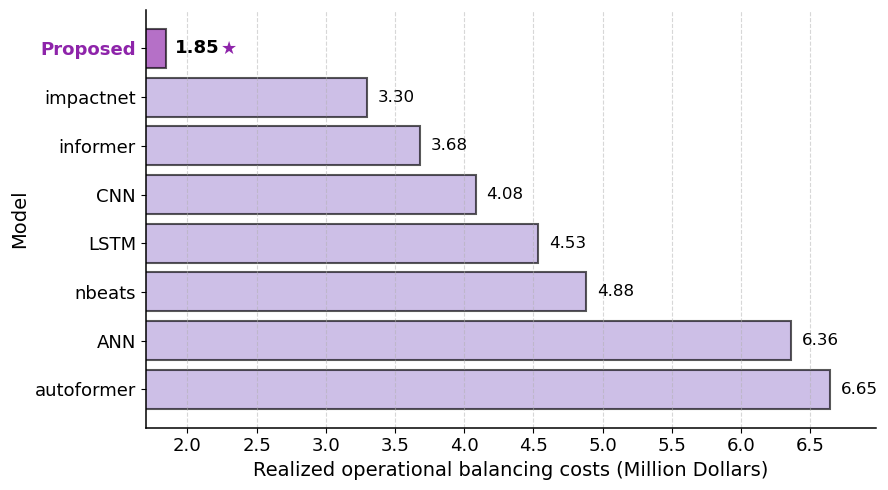

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

models = list(result_df['model'])
costs = cost_model_all
costs = np.array(costs) - np.sum(cost_actual_all)

# 排序（按成本从高到低）
models_sorted, costs_sorted = zip(*sorted(zip(models, costs), key=lambda x: x[1], reverse=True))

# ====== 紫色系颜色定义 ======
base_proposed = '#8e24aa'      # 明亮紫色
highlight_proposed = '#e1bee7' # Proposed高光
base_best = '#7c43bd'          # Best Baseline主紫
highlight_best = '#d1c4e9'     # Best Baseline高光
base_other = '#b39ddb'         # 柔和紫灰
highlight_other = '#ede7f6'    # 其他高光

def get_gradient_color(base_color, highlight_color, n):
    cmap = LinearSegmentedColormap.from_list('bar_gradient', [highlight_color, base_color])
    return [cmap(i/(n-1)) for i in range(n)]

colors_sorted = []
for m in models_sorted:
    if m == 'Proposed':
        colors_sorted.append(base_proposed)
    elif m == 'Best_Baseline':
        colors_sorted.append(base_best)
    else:
        colors_sorted.append(base_other)

# ====== 横向柱状图（单位已转为Million） ======
y = np.arange(len(models_sorted))
height = 0.8

costs_sorted_million = np.array(costs_sorted) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
rects = ax.barh(
    y, costs_sorted_million, height,
    color=colors_sorted, edgecolor='black', linewidth=1.5, alpha=0.65  # 更透明
)

# # ====== 渐变色填充（如需，取消注释） ======
# for i, rect in enumerate(rects):
#     if models_sorted[i] == 'Proposed':
#         grad = get_gradient_color(base_proposed, highlight_proposed, 100)
#     elif models_sorted[i] == 'Best_Baseline':
#         grad = get_gradient_color(base_best, highlight_best, 100)
#     else:
#         grad = get_gradient_color(base_other, highlight_other, 100)
#     x0 = rect.get_x()
#     y0 = rect.get_y()
#     width = rect.get_width()
#     height_ = rect.get_height()
#     for j, color in enumerate(grad):
#         ax.add_patch(plt.Rectangle(
#             (x0 + width * j/100, y0), width/100, height_,
#             color=color, linewidth=0
#         ))
#     rect.set_zorder(3)

# ====== 标签美化 ======
ax.set_ylabel('Model', fontsize=14, color='black')
ax.set_xlabel('Realized operational balancing costs (Million Dollars)', fontsize=14, color='black')
ax.set_yticks(y)
yticklabels = []
for m in models_sorted:
    if m == 'Proposed':
        yticklabels.append('Proposed')
    elif m == 'Best_Baseline':
        yticklabels.append('Best Baseline')
    else:
        yticklabels.append(m)
ax.set_yticklabels(yticklabels, fontsize=13, color='black')
for label, m in zip(ax.get_yticklabels(), models_sorted):
    if m == 'Proposed':
        label.set_color(base_proposed)
        label.set_fontweight('bold')
    elif m == 'Best_Baseline':
        label.set_color(base_best)
        label.set_fontweight('bold')

ax.tick_params(axis='x', labelsize=13, colors='black')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# ====== 横坐标刻度美化（以Million为单位） ======
max_million = max(costs_sorted_million)
min_million = min(costs_sorted_million)
step = 0.5
ax.xaxis.set_major_locator(ticker.MultipleLocator(step))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
ax.set_xlim(min_million*0.92, max_million*1.05)

# ====== 柱子边数字（以Million为单位） ======
for i, rect in enumerate(rects):
    value = costs_sorted_million[i]
    x = rect.get_width()
    y_ = rect.get_y() + rect.get_height() / 2
    value_str = '{:.2f}'.format(value)
    if models_sorted[i] == 'Proposed':
        ax.text(x + 0.01*max_million, y_, value_str, va='center', ha='left', fontsize=13, fontweight='bold', color='black')
        ax.text(x + 0.06*max_million, y_, '★', va='center', ha='left', fontsize=13, fontweight='bold', color=base_proposed)
    elif models_sorted[i] == 'Best_Baseline':
        ax.text(x + 0.01*max_million, y_, value_str, va='center', ha='left', fontsize=13, fontweight='bold', color='black')
        ax.text(x + 0.06*max_million, y_, '★', va='center', ha='left', fontsize=13, fontweight='bold', color=base_best)
    else:
        ax.text(x + 0.012*max_million, y_, value_str, va='center', ha='left', fontsize=12, color='black')

# ====== 边框美化 ======
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.1)
ax.spines['bottom'].set_linewidth(1.1)

# ax.set_title('Model Comparison of Cost', fontsize=16, fontweight='bold', pad=14, color='black')

plt.tight_layout()
plt.savefig('sub_figure_b.png', dpi=1000)
plt.show()


0.44301743476077715 0.1230348880583922


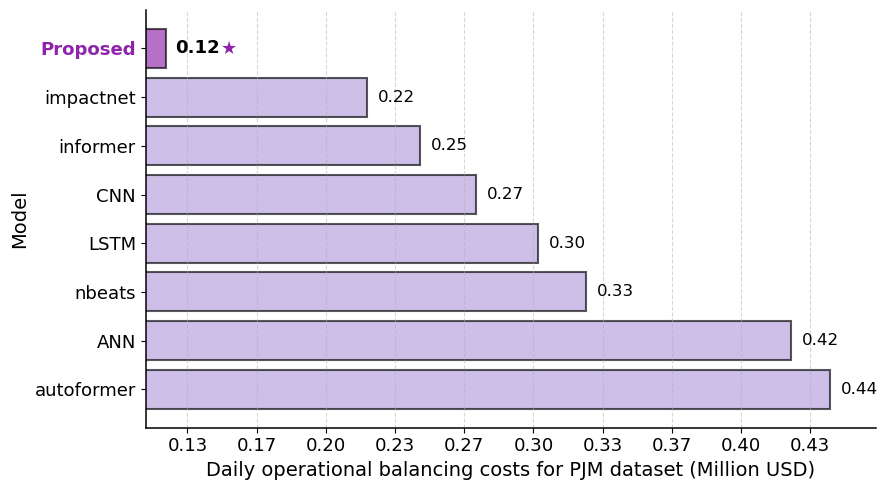

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

models = list(result_df['model'])
costs = cost_model_all
costs = np.array(costs) - np.sum(cost_actual_all)

# 排序（按成本从高到低）
models_sorted, costs_sorted = zip(*sorted(zip(models, costs), key=lambda x: x[1], reverse=True))
costs_sorted = [i/15 for i in costs_sorted]
# ====== 紫色系颜色定义 ======
base_proposed = '#8e24aa'      # 明亮紫色
highlight_proposed = '#e1bee7' # Proposed高光
base_best = '#7c43bd'          # Best Baseline主紫
highlight_best = '#d1c4e9'     # Best Baseline高光
base_other = '#b39ddb'         # 柔和紫灰
highlight_other = '#ede7f6'    # 其他高光

def get_gradient_color(base_color, highlight_color, n):
    cmap = LinearSegmentedColormap.from_list('bar_gradient', [highlight_color, base_color])
    return [cmap(i/(n-1)) for i in range(n)]

colors_sorted = []
for m in models_sorted:
    if m == 'Proposed':
        colors_sorted.append(base_proposed)
    elif m == 'Best_Baseline':
        colors_sorted.append(base_best)
    else:
        colors_sorted.append(base_other)

# ====== 横向柱状图（单位已转为Million） ======
y = np.arange(len(models_sorted))
height = 0.8

costs_sorted_million = np.array(costs_sorted) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
rects = ax.barh(
    y, costs_sorted_million, height,
    color=colors_sorted, edgecolor='black', linewidth=1.5, alpha=0.65  # 更透明
)

# # ====== 渐变色填充（如需，取消注释） ======
# for i, rect in enumerate(rects):
#     if models_sorted[i] == 'Proposed':
#         grad = get_gradient_color(base_proposed, highlight_proposed, 100)
#     elif models_sorted[i] == 'Best_Baseline':
#         grad = get_gradient_color(base_best, highlight_best, 100)
#     else:
#         grad = get_gradient_color(base_other, highlight_other, 100)
#     x0 = rect.get_x()
#     y0 = rect.get_y()
#     width = rect.get_width()
#     height_ = rect.get_height()
#     for j, color in enumerate(grad):
#         ax.add_patch(plt.Rectangle(
#             (x0 + width * j/100, y0), width/100, height_,
#             color=color, linewidth=0
#         ))
#     rect.set_zorder(3)

# ====== 标签美化 ======
ax.set_ylabel('Model', fontsize=14, color='black')
ax.set_xlabel('Daily operational balancing costs for PJM dataset (Million USD)', fontsize=14, color='black')
ax.set_yticks(y)
yticklabels = []
for m in models_sorted:
    if m == 'Proposed':
        yticklabels.append('Proposed')
    elif m == 'Best_Baseline':
        yticklabels.append('Best Baseline')
    else:
        yticklabels.append(m)
ax.set_yticklabels(yticklabels, fontsize=13, color='black')
for label, m in zip(ax.get_yticklabels(), models_sorted):
    if m == 'Proposed':
        label.set_color(base_proposed)
        label.set_fontweight('bold')
    elif m == 'Best_Baseline':
        label.set_color(base_best)
        label.set_fontweight('bold')

ax.tick_params(axis='x', labelsize=13, colors='black')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# ====== 横坐标刻度美化（以Million为单位） ======
max_million = max(costs_sorted_million)
min_million = min(costs_sorted_million)
print(max_million,min_million)
step = 0.5/15
ax.xaxis.set_major_locator(ticker.MultipleLocator(step))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: '{:.2f}'.format(x)))
ax.set_xlim(min_million*0.92, max_million*1.05)

# ====== 柱子边数字（以Million为单位） ======
for i, rect in enumerate(rects):
    value = costs_sorted_million[i]
    x = rect.get_width()
    y_ = rect.get_y() + rect.get_height() / 2
    value_str = '{:.2f}'.format(value)
    if models_sorted[i] == 'Proposed':
        ax.text(x + 0.01*max_million, y_, value_str, va='center', ha='left', fontsize=13, fontweight='bold', color='black')
        ax.text(x + 0.06*max_million, y_, '★', va='center', ha='left', fontsize=13, fontweight='bold', color=base_proposed)
    elif models_sorted[i] == 'Best_Baseline':
        ax.text(x + 0.01*max_million, y_, value_str, va='center', ha='left', fontsize=13, fontweight='bold', color='black')
        ax.text(x + 0.06*max_million, y_, '★', va='center', ha='left', fontsize=13, fontweight='bold', color=base_best)
    else:
        ax.text(x + 0.012*max_million, y_, value_str, va='center', ha='left', fontsize=12, color='black')

# ====== 边框美化 ======
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.1)
ax.spines['bottom'].set_linewidth(1.1)

# ax.set_title('Model Comparison of Cost', fontsize=16, fontweight='bold', pad=14, color='black')

plt.tight_layout()
plt.savefig('sub_figure_b.png', dpi=1000)
plt.show()


In [19]:
print('Compared to the best baseline, the daily cost saving is:')
print(costs_sorted[-2]-costs_sorted[-1])

Compared to the best baseline, the daily cost saving is:
96801.72765487035


In [20]:
import os
import pandas as pd

cost_saving_all={}
for filename in file_name_list:
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path+'.csv')
    dataframes[name_to_code[filename[8:]]] = df

    DA_price=DA_price_data[DA_price_data['pnode_name']==name_to_code[filename[8:]]].iloc[0:480]['total_lmp_da']
    DA_price=list(DA_price)
    RT_price=RT_price_data[RT_price_data['pnode_name']==name_to_code[filename[8:]]].iloc[0:480]['total_lmp_rt']
    RT_price=list(RT_price)

    benchmake_forecasts=dataframes[name_to_code[filename[8:]]]['Baseline']
    actual_load=dataframes[name_to_code[filename[8:]]]['True']
    proposed_forecasts=dataframes[name_to_code[filename[8:]]]['Proposed']

    print(MAPE(np.array(actual_load),np.array(benchmake_forecasts)))
    print(MAPE(np.array(actual_load),np.array(proposed_forecasts)))

    benchmark_acc[name_to_code[filename[8:]]]=MAPE(np.array(actual_load),np.array(benchmake_forecasts))
    proposed_acc[name_to_code[filename[8:]]]=MAPE(np.array(actual_load),np.array(proposed_forecasts))

    costs_benchmark=np.array(benchmake_forecasts)*np.array(DA_price)\
        +(actual_load-benchmake_forecasts)*np.array(RT_price)
    costs_proposed=np.array(proposed_forecasts)*np.array(DA_price)\
        +(actual_load-proposed_forecasts)*np.array(RT_price)
    cost_saving=costs_benchmark-costs_proposed

    deviation_baseline=np.array(actual_load)-np.array(benchmake_forecasts)
    deviation_baseline[deviation_baseline<0]=0
    deviation_proposed=np.array(actual_load)-np.array(proposed_forecasts)
    deviation_proposed[deviation_proposed<0]=0
    deviation=deviation_baseline-deviation_proposed

    max_ratio_index = np.argmax(np.array(RT_price)/np.array(DA_price))
    print(max(np.array(RT_price)/np.array(DA_price)),RT_price[max_ratio_index], DA_price[max_ratio_index])
    max_deviation_index = np.argmax(np.abs(np.array(RT_price)-np.array(DA_price)))
    print(max(np.abs(np.array(RT_price)-np.array(DA_price))),RT_price[max_deviation_index], DA_price[max_deviation_index])
    print(print(RT_price_data[RT_price_data['pnode_name']==name_to_code[filename[8:]]].iloc[max_deviation_index:max_deviation_index+1]['datetime_beginning_utc']))
    print(np.array(actual_load)[max_deviation_index],np.array(benchmake_forecasts)[max_deviation_index],np.array(proposed_forecasts)[max_deviation_index])

    print('Total cost saving:',sum(cost_saving))
    cost_saving_all[filename[8:]]=sum(cost_saving)
    total_cost=np.array(actual_load)*np.array(DA_price)#+(deviation_baseline)*np.array(RT_price)
    #plot the saving of each day （24h per day）
    costs_saving_daily=np.array(cost_saving).reshape(-1,24)
    costs_saving_daily=np.sum(costs_saving_daily,axis=1)
    
total_saving=0
for filename in file_name_list:
    total_saving+=cost_saving_all[filename[8:]]
print(total_saving)


print(sum(cost_saving_all.values()))
print(len(cost_saving_all))

4.282278497500731
3.908214598670224
4.552145691867378 113.539413 24.941955
184.664439 248.512366 63.847927
4818    7/5/2023 9:00:00 PM
Name: datetime_beginning_utc, dtype: object
None
8677.74535008581 8178.180321973952 8442.78164726827
Total cost saving: 265800.4379617835
4.177504825898956
4.142071350936576
4.353820743954904 166.648728 38.276433
174.85138400000002 259.957529 85.106145
4810    7/5/2023 9:00:00 PM
Name: datetime_beginning_utc, dtype: object
None
5389.07001480042 5389.014683273999 5692.6576503537
Total cost saving: -9608.48674668961
4.644158804816161
3.952902627459169
3.550068191233891 245.905062 69.267701
176.637361 245.905062 69.267701
4825    7/5/2023 9:00:00 PM
Name: datetime_beginning_utc, dtype: object
None
2416.90100128372 2242.7079710666 2252.400585321348
Total cost saving: -24604.00688855705
4.011004161768543
3.2532973010573856
14.327592967498783 491.343553 34.293517
495.76522099999994 660.356917 164.591696
8698    7/12/2023 10:00:00 PM
Name: datetime_beginning_u

In [25]:
import os
import pandas as pd

filename='results_Delmarva Power and Light'
# filename='results_ComEd'
file_path = os.path.join(folder_path, filename)
df = pd.read_csv('process_result/DPL'+'.csv')
# df = pd.read_csv(file_path+'.csv')

start=48+3*24
end=start+24*1
length= end - start
print(filename[8:])
print(name_to_code[filename[8:]])
# 你可以根据需要添加更多格式

DA_price=DA_price_data[DA_price_data['pnode_name']==name_to_code[filename[8:]]].iloc[start:end]['total_lmp_da']
DA_price=list(DA_price)
RT_price=RT_price_data[RT_price_data['pnode_name']==name_to_code[filename[8:]]].iloc[start:end]['total_lmp_rt']
RT_price=list(RT_price)

#DA_price=DA_price_data[DA_price_data['pnode_name']==name_to_code[filename[8:]]].iloc[0:480]['system_energy_price_da']
#RT_price=RT_price_data[RT_price_data['pnode_name']==name_to_code[filename[8:]]].iloc[0:480]['system_energy_price_rt']
# print(filename[8:])
# print(name_to_code[filename[8:]])
# print(np.mean(DA_price),np.mean(RT_price))
# print(DA_price[0:5])

# plt.plot(DA_price,label='DA_price')
# plt.plot(RT_price,label='RT_price')
# plt.legend()
# plt.show()
benchmake_forecasts=df['CNN'][start-48:end-48]
actual_load=df['Actual'][start-48:end-48]
proposed_forecasts=df['Proposed'][start-48:end-48]

print(MAPE(np.array(actual_load),np.array(benchmake_forecasts)))
print(MAPE(np.array(actual_load),np.array(proposed_forecasts)))

benchmark_acc[name_to_code[filename[8:]]]=MAPE(np.array(actual_load),np.array(benchmake_forecasts))
proposed_acc[name_to_code[filename[8:]]]=MAPE(np.array(actual_load),np.array(proposed_forecasts))

print(len(benchmake_forecasts))
costs_benchmark=np.array(benchmake_forecasts)*np.array(DA_price)\
    +(actual_load-benchmake_forecasts)*np.array(RT_price)
costs_proposed=np.array(proposed_forecasts)*np.array(DA_price)\
    +(actual_load-proposed_forecasts)*np.array(RT_price)
cost_saving=costs_benchmark-costs_proposed


print('Total cost saving:',sum(cost_saving))
cost_saving_all[name_to_code[filename[8:]]]=sum(cost_saving)
total_cost=np.array(actual_load)*np.array(DA_price)#+(deviation_baseline)*np.array(RT_price)
#plot the saving of each day （24h per day）
costs_saving_daily=np.array(cost_saving).reshape(-1,24)
costs_saving_daily=np.sum(costs_saving_daily,axis=1)

print(max(DA_price))
print(max(RT_price))
print(max(RT_price)-max(DA_price))
print(max(np.array(RT_price)/np.array(DA_price)))

Delmarva Power and Light
DPL
6.9565824604209
3.7069319115234376
24
Total cost saving: 264755.2424648632
42.3497
491.343553
448.993853
14.327592967498783


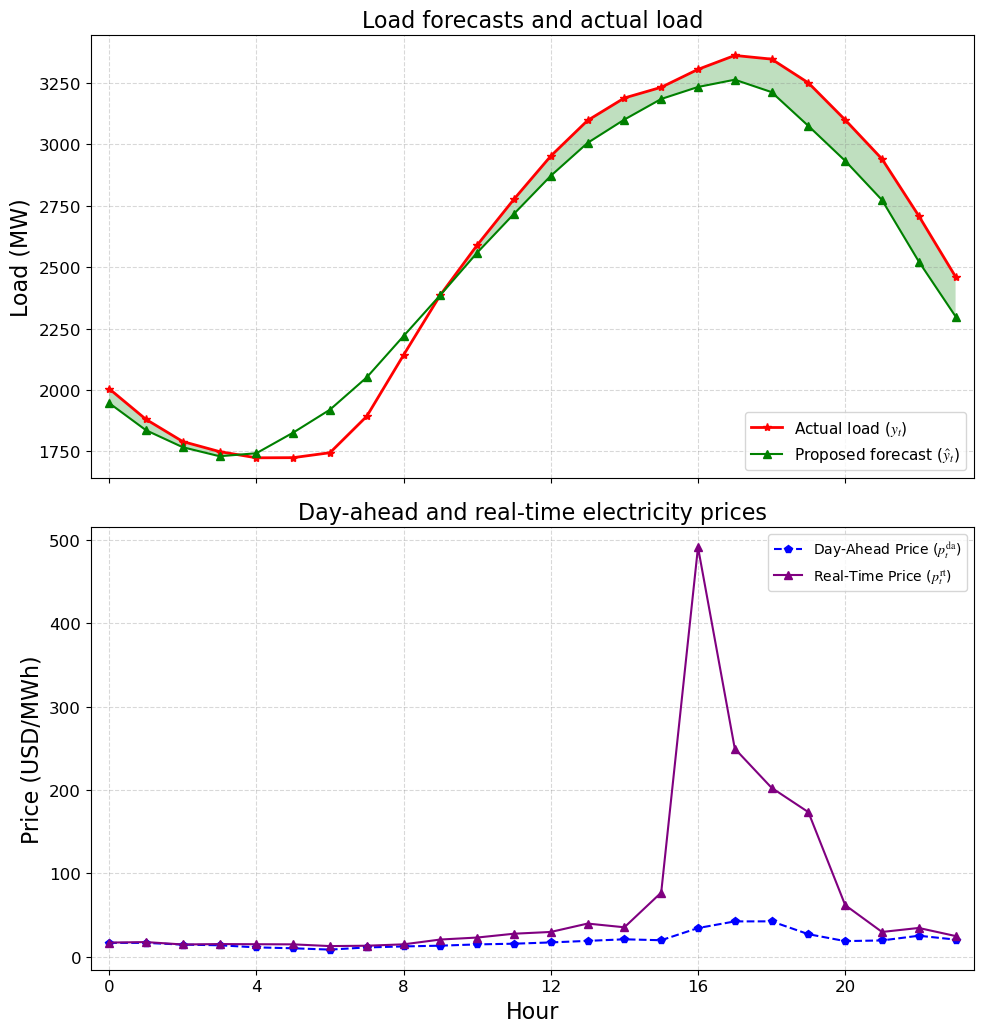

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.size'] = 12
#['dejavusans', 'dejavuserif', 'cm', 'stix', 'stixsans', 'custom']
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
# plt.rcParams['font.family'] = 'STIXGeneral'

plt.rcParams['font.size'] = 12
plt.rcParams['mathtext.fontset'] = 'stix'
#plt.rcParams['font.family'] = 'STIXGeneral'

# 假设这里是你的起止点以及提取的一维数据
x = np.arange(24)
bench_slice = np.array(benchmake_forecasts).flatten()
proposed_slice = np.array(proposed_forecasts).flatten()
actual_slice = np.array(actual_load).flatten()
DA_slice = np.array(DA_price).flatten()
RT_slice = np.array(RT_price).flatten()

# ====================================================================
# （此处假设 x, actual_slice, bench_slice, proposed_slice, DA_slice, RT_slice 已准备好）
# ====================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10.5), sharex=True)
fig.subplots_adjust(hspace=0.08) 

x_start = -0.5
x_sep1 = 3.5  # 第一刀：切在下降期结束，准备进入红框的位置
x_sep2 = 7 # 第二刀：切在红框结束，大蓝天开始的地方
x_end = 23.5

# 时段 1 (淡橙色)
# color1 = '#FFF8EE'
# ax1.axvspan(x_start, x_sep1, facecolor=color1, alpha=0.9, zorder=0, edgecolor='none')
# ax2.axvspan(x_start, x_sep1, facecolor=color1, alpha=0.9, zorder=0, edgecolor='none')

# --------- 上半图：负荷比较 ----------
ax1.plot(x, actual_slice, label='Actual load ($y_t$)', color='red', linewidth=2, marker='*')
#ax1.plot(x, bench_slice, label='Benchmark forecast ($\hat{y}^{\mathrm{base}}_t$)', color='red', linestyle='--', marker='o')
ax1.plot(x, proposed_slice, label='Proposed forecast ($\hat{y}_t$)', color='green', linestyle='-', marker='^')

# 缺口填充
ax1.fill_between(x, actual_slice, proposed_slice,
                 where=(actual_slice > proposed_slice),
                 facecolor='green', alpha=0.25, interpolate=True)

# =================================================================
# 🌟 【绝对服从截图的三段硬切线】 🌟
# x_sep1 和 x_sep2 是两道分割线。
# 因为数据点在整数上，我们切在半整数(例如 x.5)上，让颜色边缘正好在两个点中间断开。
# =================================================================
x_start = -0.5
x_sep1 = 3.5  # 第一刀：切在下降期结束，准备进入红框的位置
x_sep2 = 7.5  # 第二刀：切在红框结束，大蓝天开始的地方
x_end = 23.5

# # 时段 1 (淡橙色)
# color1 = '#FFF8EE'
# ax1.axvspan(x_start, x_sep1, facecolor=color1, alpha=0.9, zorder=0, edgecolor='none')
# ax2.axvspan(x_start, x_sep1, facecolor=color1, alpha=0.6, zorder=0, edgecolor='none')

# # 时段 2 (淡紫色) —— 完美对应你的红框区域！
# color2 = '#F8F1FF'
# ax1.axvspan(x_sep1, x_sep2, facecolor=color2, alpha=0.9, zorder=0, edgecolor='none')
# ax2.axvspan(x_sep1, x_sep2, facecolor=color2, alpha=0.6, zorder=0, edgecolor='none')

# # 时段 3 (淡蓝色) —— 你的阶段3，无边无际的蓝色爬坡
# color3 = '#F0F7FF'
# ax1.axvspan(x_sep2, x_end, facecolor=color3, alpha=0.9, zorder=0, edgecolor='none')
# ax2.axvspan(x_sep2, x_end, facecolor=color3, alpha=0.6, zorder=0, edgecolor='none')
# # =================================================================

ax1.set_title('Load forecasts and actual load', fontsize=16)
ax1.set_ylabel('Load (MW)', fontsize=16)
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, linestyle='--', color='gray', alpha=0.3) 

# --------- 下半图：电价差 ----------
ax2.plot(x, DA_slice, label='Day-Ahead Price ($p^{\mathrm{da}}_t$)', color='blue', linestyle='--', marker='p')
ax2.plot(x, RT_slice, label='Real-Time Price ($p^{\mathrm{rt}}_t$)', color='purple', linestyle='-', marker='^')

# idx_peak = np.argmax(RT_slice) 
# ax2.annotate('', xy=(x[idx_peak], DA_slice[idx_peak]), 
#              xytext=(x[idx_peak], RT_slice[idx_peak]),
#              arrowprops=dict(arrowstyle='<|-|>', color='black', lw=1.5))

ax2.set_title('Day-ahead and real-time electricity prices', fontsize=16)
ax2.set_xlabel('Hour', fontsize=16)
ax2.set_ylabel('Price (USD/MWh)', fontsize=16)
ax2.legend(loc='upper right', fontsize=10) 
ax2.grid(True, linestyle='--', color='gray', alpha=0.3)

# ax1.axvline(x=x[idx_peak], color='gray', linestyle=':', alpha=0.8, lw=1.5)
# ax2.axvline(x=x[idx_peak], color='gray', linestyle=':', alpha=0.8, lw=1.5)

ax2.set_xticks(np.arange(0, 25, 4))
ax2.set_xlim(-0.5, 23.5)

plt.tight_layout()
plt.savefig('sub_figure_b.png', dpi=1000, bbox_inches='tight')
plt.show()